## Classification of Diabetic Retinopathy images using ResNet


## Initial Imports and Setup

In [2]:
import os
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras import layers
from tensorflow.keras.models import Model
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from collections import Counter

# Set random seeds for reproducibility
tf.random.set_seed(42)
np.random.seed(42)
print("TensorFlow version:", tf.__version__)

/Users/susheel/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


TensorFlow version: 2.13.0


In [3]:
# Configuration
IMG_SIZE = 244  # Your preprocessed image size
BATCH_SIZE = 32
EPOCHS = 30
NUM_CLASSES = 5
AUTOTUNE = tf.data.AUTOTUNE

# Define paths
BASE_DIR = './Dataset'
IMAGE_DIR = os.path.join(BASE_DIR, 'resize_images')

# Create class mapping
class_mapping = {
    'No disease': 0,
    'Mild': 1,
    'Moderate': 2,
    'Severe': 3,
    'Proliferate': 4
}

# Reverse mapping for visualization
label_descriptions = {v: k for k, v in class_mapping.items()}

## Recreate the filtered_labels_dict from the preprocessed CSV

In [4]:
# Load original labels
labels_path = './Dataset/trainLabels.csv'
labels_df = pd.read_csv(labels_path)

# Map descriptions
label_descriptions = {
    0: "No disease",
    1: "Mild",
    2: "Moderate",
    3: "Severe",
    4: "Proliferate"
}
labels_df['description'] = labels_df['level'].map(label_descriptions)

# Create labels dictionary
labels_dict = dict(zip(labels_df['image'], labels_df['description']))

# Get list of actual images in your preprocessed directory
existing_images = [f.replace('.jpeg', '') for f in os.listdir(IMAGE_DIR) if f.endswith('.jpeg')]

# Create filtered dictionary only for images that exist in your preprocessed folder
filtered_labels_dict = {img: labels_dict[img] for img in existing_images if img in labels_dict}

print("Labels loaded!")
print("\nDistribution of classes:")
print(Counter(filtered_labels_dict.values()))

Labels loaded!

Distribution of classes:
Counter({'No disease': 10810, 'Moderate': 5292, 'Mild': 2443, 'Severe': 873, 'Proliferate': 708})


In [5]:
# Use your filtered_labels_dict to create the dataset
image_paths = []
labels = []

for img_name, label in filtered_labels_dict.items():
    img_path = os.path.join(IMAGE_DIR, f"{img_name}.jpeg")
    if os.path.exists(img_path):
        image_paths.append(img_path)
        labels.append(class_mapping[label])

# Convert to numpy arrays
image_paths = np.array(image_paths)
labels = np.array(labels)

print("Total images:", len(image_paths))
print("\nClass distribution:")
for i in range(NUM_CLASSES):
    print(f"{label_descriptions[i]}: {np.sum(labels == i)}")

Total images: 20126

Class distribution:
No disease: 10810
Mild: 2443
Moderate: 5292
Severe: 873
Proliferate: 708


## Split into train and test data

In [ ]:
# Split into train, validation, and test sets
X_train, X_temp, y_train, y_temp = train_test_split(
    image_paths, labels, test_size=0.3, random_state=42, stratify=labels
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)
print("Train set size:", len(X_train))
print("Validation set size:", len(X_val))
print("Test set size:", len(X_test))

Train set size: 14088
Validation set size: 3019
Test set size: 3019


## Create Dataset Pipleine

In [7]:
def load_and_preprocess_image(image_path):
    # Read image
    img = tf.io.read_file(image_path)
    img = tf.image.decode_jpeg(img, channels=3)
    
    # Convert to float32
    img = tf.cast(img, tf.float32)
    
    return img

def augment(image):
    # Random flip
    image = tf.image.random_flip_left_right(image)
    image = tf.image.random_flip_up_down(image)
    
    # Random rotation
    image = tf.image.rot90(image, tf.random.uniform(shape=[], minval=0, maxval=4, dtype=tf.int32))
    
    # Random brightness and contrast
    image = tf.image.random_brightness(image, 0.2)
    image = tf.image.random_contrast(image, 0.8, 1.2)
    
    return image

def prepare_dataset(image_paths, labels, is_training=False):
    dataset = tf.data.Dataset.from_tensor_slices((image_paths, labels))
    
    def process_path(path, label):
        img = load_and_preprocess_image(path)
        if is_training:
            img = augment(img)
        return img, label
    
    dataset = dataset.map(process_path, num_parallel_calls=AUTOTUNE)
    dataset = dataset.batch(BATCH_SIZE)
    dataset = dataset.prefetch(AUTOTUNE)
    
    return dataset

In [8]:
# Create training, validation, and test datasets
train_ds = prepare_dataset(X_train, y_train, is_training=True)
val_ds = prepare_dataset(X_val, y_val)
test_ds = prepare_dataset(X_test, y_test)

2024-11-18 18:06:32.836366: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M3 Pro
2024-11-18 18:06:32.836408: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 18.00 GB
2024-11-18 18:06:32.836421: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 6.00 GB
2024-11-18 18:06:32.836516: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:303] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2024-11-18 18:06:32.836566: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:269] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


In [9]:
# Calculate class weights for imbalanced dataset
total_samples = len(y_train)
n_classes = len(class_mapping)
class_counts = np.bincount(y_train)
class_weights = {}

for i in range(n_classes):
    class_weights[i] = total_samples / (n_classes * class_counts[i])

print("Class weights:", class_weights)

Class weights: {0: 0.3723536408087749, 1: 1.6477192982456141, 2: 0.7606911447084234, 3: 4.611456628477905, 4: 5.680645161290323}


## Create Model

In [10]:
def create_resnet_model():
    # Load the ResNet50 model
    base_model = tf.keras.applications.ResNet50(
        weights='imagenet',
        include_top=False,
        input_shape=(IMG_SIZE, IMG_SIZE, 3)
    )
    
    # Freeze the base model
    base_model.trainable = False
    
    # Create new model on top
    inputs = tf.keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
    x = tf.keras.applications.resnet50.preprocess_input(inputs)
    x = base_model(x, training=False)
    x = tf.keras.layers.GlobalAveragePooling2D()(x)
    x = tf.keras.layers.Dense(512, activation='relu')(x)
    x = tf.keras.layers.Dropout(0.3)(x)
    outputs = tf.keras.layers.Dense(NUM_CLASSES, activation='softmax')(x)
    
    model = tf.keras.Model(inputs, outputs)
    
    return model

# Create and compile the model
model = create_resnet_model()
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Display model summary
model.summary()

94765736/94765736 [==============================] - 2s 0us/step


Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_2 (InputLayer)        [(None, 244, 244, 3)]     0         
                                                                 
 tf.__operators__.getitem (  (None, 244, 244, 3)       0         
 SlicingOpLambda)                                                
                                                                 
 tf.nn.bias_add (TFOpLambda  (None, 244, 244, 3)       0         
 )                                                               
                                                                 
 resnet50 (Functional)       (None, 8, 8, 2048)        23587712  
                                                                 
 global_average_pooling2d (  (None, 2048)              0         
 GlobalAveragePooling2D)                                         
                                                             

## Model Train

In [11]:
# Create checkpoint directory
checkpoint_dir = './model_checkpoints'
os.makedirs(checkpoint_dir, exist_ok=True)

# Create callbacks
callbacks = [
    tf.keras.callbacks.ModelCheckpoint(
        filepath=os.path.join(checkpoint_dir, 'best_model.h5'),
        monitor='val_accuracy',
        save_best_only=True,
        mode='max',
        verbose=1
    ),
    tf.keras.callbacks.EarlyStopping(
        monitor='val_accuracy',
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.2,
        patience=3,
        min_lr=1e-6,
        verbose=1
    ),
    tf.keras.callbacks.CSVLogger('training_log.csv')
]

In [12]:
# Train the model
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=callbacks,
    class_weight=class_weights
)

Epoch 1/30


2024-11-18 18:06:44.088848: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


441/441 [==============================] - ETA: 0s - loss: 2.2204 - accuracy: 0.2837

2024-11-18 18:08:06.445195: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.



Epoch 1: val_accuracy improved from -inf to 0.15634, saving model to ./model_checkpoints/best_model.h5


/Users/susheel/Library/Python/3.9/lib/python/site-packages/keras/src/engine/training.py:3000: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


441/441 [==============================] - 101s 224ms/step - loss: 2.2204 - accuracy: 0.2837 - val_loss: 2.2012 - val_accuracy: 0.1563 - lr: 0.0010
Epoch 2/30
441/441 [==============================] - ETA: 0s - loss: 1.6587 - accuracy: 0.3271
Epoch 2: val_accuracy did not improve from 0.15634
441/441 [==============================] - 95s 215ms/step - loss: 1.6587 - accuracy: 0.3271 - val_loss: 2.3227 - val_accuracy: 0.1534 - lr: 0.0010
Epoch 3/30
441/441 [==============================] - ETA: 0s - loss: 1.5536 - accuracy: 0.3455
Epoch 3: val_accuracy improved from 0.15634 to 0.15767, saving model to ./model_checkpoints/best_model.h5
441/441 [==============================] - 92s 208ms/step - loss: 1.5536 - accuracy: 0.3455 - val_loss: 2.2786 - val_accuracy: 0.1577 - lr: 0.0010
Epoch 4/30
441/441 [==============================] - ETA: 0s - loss: 1.5192 - accuracy: 0.3533
Epoch 4: val_accuracy improved from 0.15767 to 0.16197, saving model to ./model_checkpoints/best_model.h5
441/441

## Plot Results

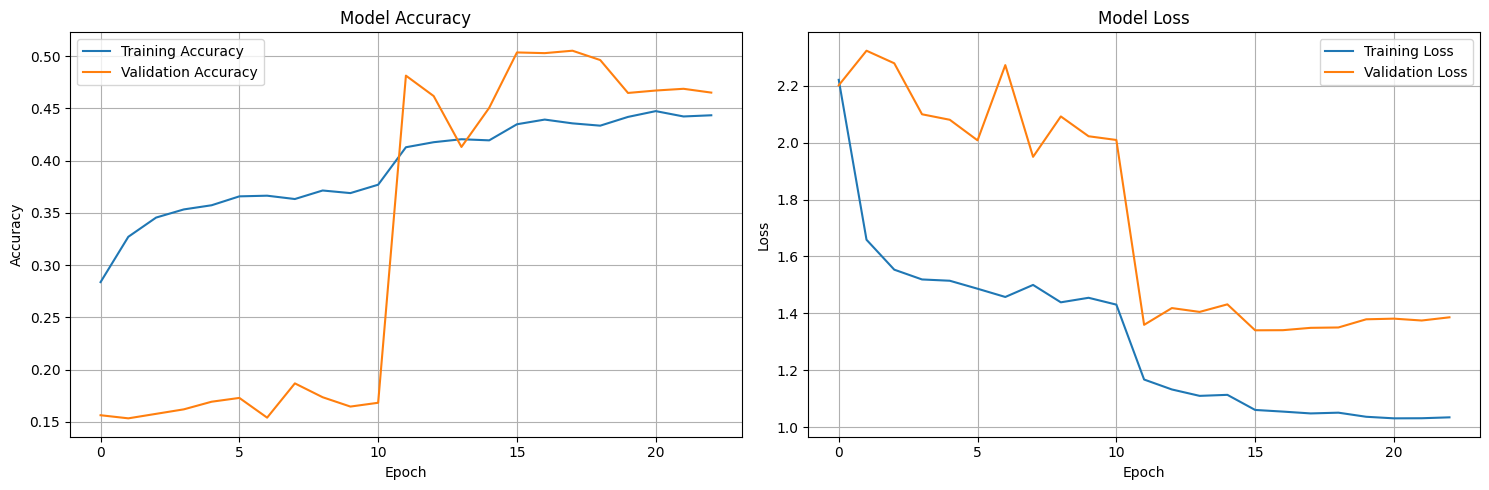

In [13]:
def plot_training_history(history):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
    
    # Plot accuracy
    ax1.plot(history.history['accuracy'], label='Training Accuracy')
    ax1.plot(history.history['val_accuracy'], label='Validation Accuracy')
    ax1.set_title('Model Accuracy')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Accuracy')
    ax1.legend()
    ax1.grid(True)
    
    # Plot loss
    ax2.plot(history.history['loss'], label='Training Loss')
    ax2.plot(history.history['val_loss'], label='Validation Loss')
    ax2.set_title('Model Loss')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Loss')
    ax2.legend()
    ax2.grid(True)
    
    plt.tight_layout()
    plt.show()

# Plot the training history
plot_training_history(history)

In [14]:
# Evaluate the model on test set
test_loss, test_accuracy = model.evaluate(test_ds)
print(f"\nTest accuracy: {test_accuracy:.4f}")
print(f"Test loss: {test_loss:.4f}")

95/95 [==============================] - 15s 155ms/step - loss: 1.3695 - accuracy: 0.4912

Test accuracy: 0.4912
Test loss: 1.3695


##  Evaluation Metrics

2024-11-18 18:43:21.161833: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2024-11-18 18:43:37.671754: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


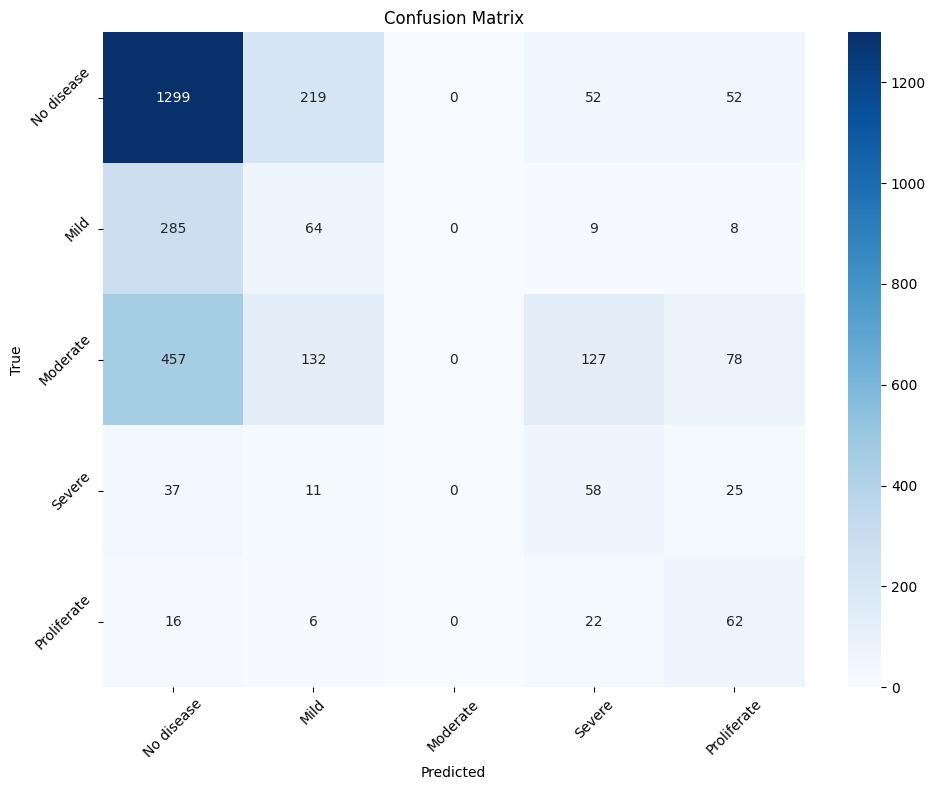


Classification Report:
              precision    recall  f1-score   support

  No disease       0.62      0.80      0.70      1622
        Mild       0.15      0.17      0.16       366
    Moderate       0.00      0.00      0.00       794
      Severe       0.22      0.44      0.29       131
 Proliferate       0.28      0.58      0.37       106

    accuracy                           0.49      3019
   macro avg       0.25      0.40      0.30      3019
weighted avg       0.37      0.49      0.42      3019



/Users/susheel/Library/Python/3.9/lib/python/site-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/Users/susheel/Library/Python/3.9/lib/python/site-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/Users/susheel/Library/Python/3.9/lib/python/site-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


In [15]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

def evaluate_model(model, dataset, class_names):
    # Get predictions
    y_pred = []
    y_true = []
    
    for images, labels in dataset:
        pred = model.predict(images, verbose=0)
        y_pred.extend(np.argmax(pred, axis=1))
        y_true.extend(labels.numpy())
    
    # Create confusion matrix
    cm = confusion_matrix(y_true, y_pred)
    
    # Plot confusion matrix
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names,
                yticklabels=class_names)
    plt.title('Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.xticks(rotation=45)
    plt.yticks(rotation=45)
    plt.tight_layout()
    plt.show()
    
    # Print classification report
    print("\nClassification Report:")
    print(classification_report(y_true, y_pred, 
                              target_names=class_names))

# Get class names in order
class_names = [label_descriptions[i] for i in range(NUM_CLASSES)]

# Evaluate model
evaluate_model(model, test_ds, class_names)

## Test Model 

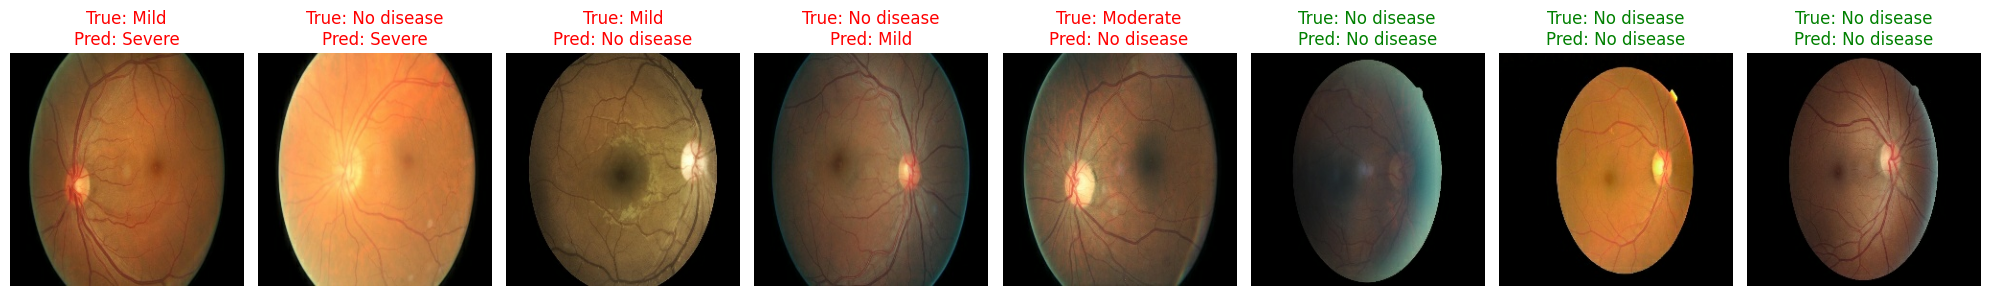

In [16]:
def visualize_predictions(model, dataset, class_names, num_images=8):
    # Get a batch of images and labels
    for images, labels in dataset.take(1):
        # Make predictions
        predictions = model.predict(images, verbose=0)
        pred_labels = np.argmax(predictions, axis=1)
        
        # Plot images
        plt.figure(figsize=(20, 4))
        for i in range(min(num_images, len(images))):
            plt.subplot(1, num_images, i + 1)
            plt.imshow(images[i].numpy().astype("uint8"))
            color = 'green' if pred_labels[i] == labels[i] else 'red'
            plt.title(f'True: {class_names[labels[i]]}\nPred: {class_names[pred_labels[i]]}',
                     color=color)
            plt.axis('off')
        plt.tight_layout()
        plt.show()

# Visualize some predictions
visualize_predictions(model, test_ds, class_names)